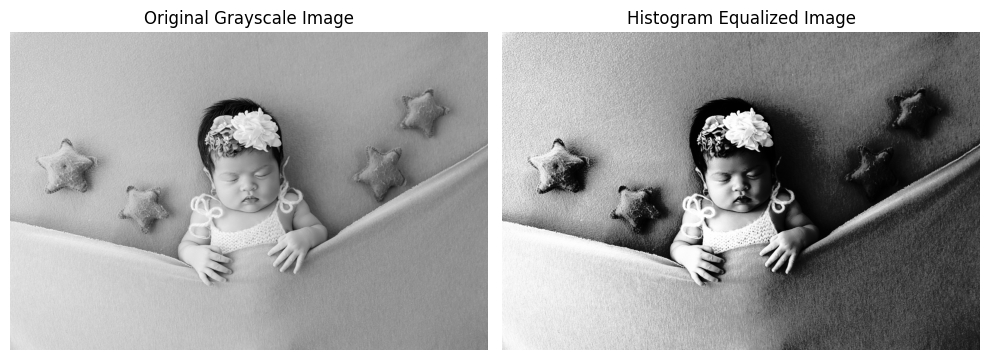

In [1]:
# Assignment-6
# ● Write a program to enhance the contrast of the input grayscale image using histogram equalization. Display the original image and equalized image.

import cv2
import matplotlib.pyplot as plt

image = cv2.imread("baby.jpg.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found!")
    exit()

equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.tight_layout()
plt.show()

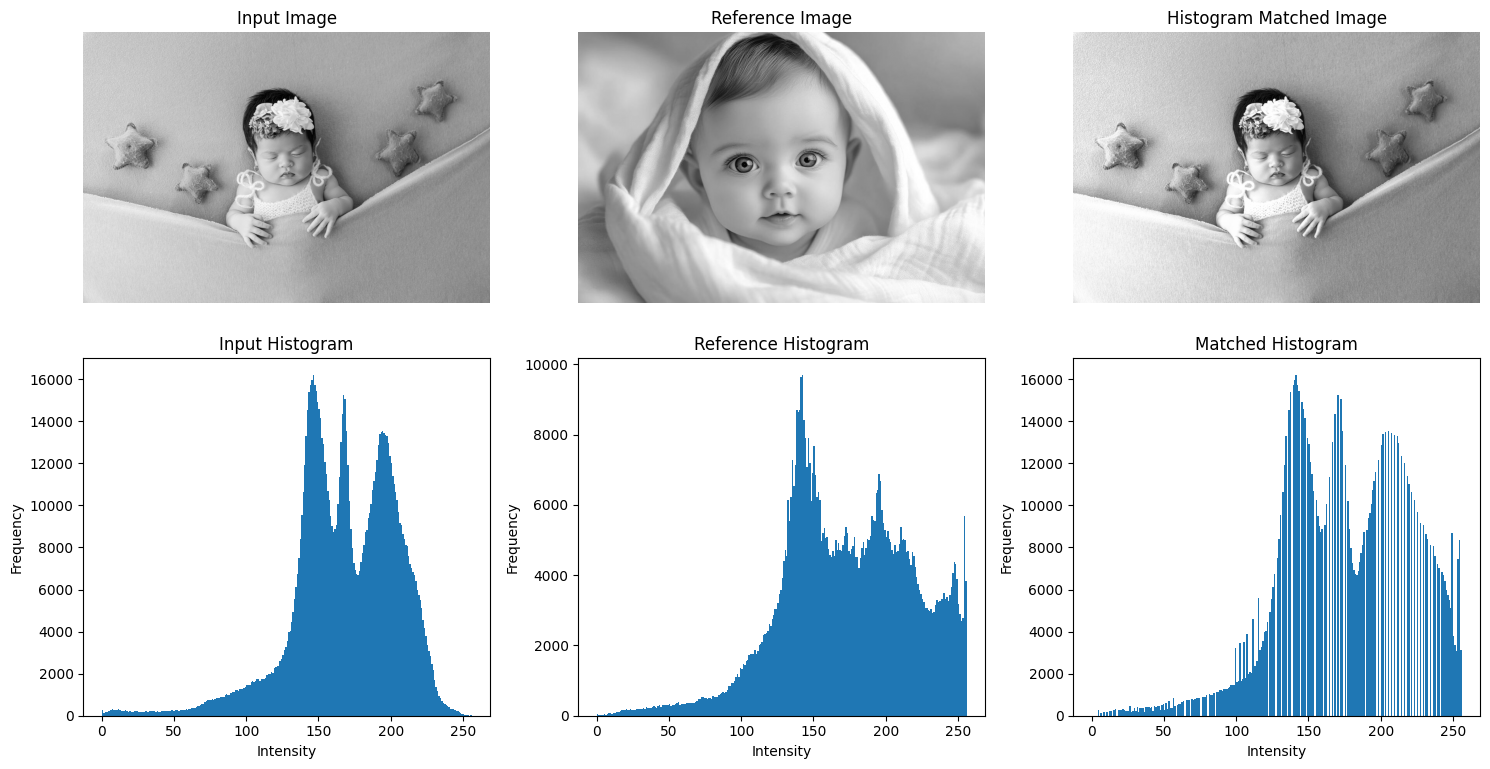

In [3]:
# Write a program to perform histogram matching of the input image with that of reference image using histogram equalization.

import cv2
import numpy as np
import matplotlib.pyplot as plt

input_image = cv2.imread("baby.jpg.jpg", cv2.IMREAD_GRAYSCALE)
reference_image = cv2.imread("baby1.jpg", cv2.IMREAD_GRAYSCALE)
if input_image is None:
    print("Error: Input image not found!")
    exit()

if reference_image is None:
    print("Error: Reference image not found!")
    exit()

input_hist = cv2.calcHist([input_image], [0], None, [256], [0, 256])
reference_hist = cv2.calcHist([reference_image], [0], None, [256], [0, 256])
input_cdf = input_hist.cumsum()
reference_cdf = reference_hist.cumsum()
input_cdf = input_cdf / input_cdf[-1]
reference_cdf = reference_cdf / reference_cdf[-1]

mapping = np.zeros(256, dtype=np.uint8)

for input_pixel in range(256):
    difference = np.abs(reference_cdf - input_cdf[input_pixel])

    reference_pixel = np.argmin(difference)

    mapping[input_pixel] = reference_pixel

matched_image = mapping[input_image]

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(input_image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(reference_image, cmap="gray")
plt.title("Reference Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(matched_image, cmap="gray")
plt.title("Histogram Matched Image")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.hist(input_image.ravel(), bins=256, range=[0, 256])
plt.title("Input Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(2, 3, 5)
plt.hist(reference_image.ravel(), bins=256, range=[0, 256])
plt.title("Reference Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(2, 3, 6)
plt.hist(matched_image.ravel(), bins=256, range=[0, 256])
plt.title("Matched Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()